In [1]:
import random
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc,
)
import nibabel as nib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib import rcParams

import matplotlib.pyplot as plt
import seaborn as sns 
from tqdm import tqdm

# Local/project modules 
from helpers.run_models import train, test
from helpers.models import * 
from helpers.ConvolutionalAE import ConvolutionalAE_upd
from helpers.utils import *



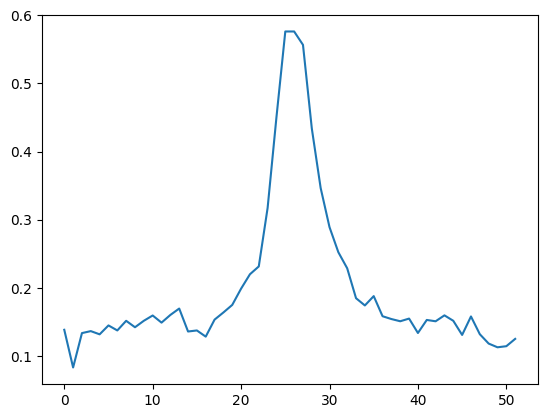

In [ ]:
rat_data_postGAD = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
Rat_Z_Spectras = 1- rat_data_postGAD['zspec']
Rat_Healthy_Idx = rat_data_postGAD['voxelInds_healthy']
Rat_Tumor_Idx = rat_data_postGAD['voxelInds_tumor']
rat_healthy_all = Rat_Z_Spectras[Rat_Healthy_Idx]
rat_tumor_all = Rat_Z_Spectras[Rat_Tumor_Idx]

plt.plot(rat_healthy_all[0])


In [3]:
rat_data_HEALTHY_TRAIN = np.load('data/ratData_healthy_all4_rats.npz')
Rat_Z_Spectras_HEALTHY_TRAIN = 1- rat_data_HEALTHY_TRAIN['zspec']
Rat_Healthy_Idx__HEALTHY_TRAIN = rat_data_HEALTHY_TRAIN['voxelInds_healthy']
rat_healthy_all_HEALTHY_TRAIN = Rat_Z_Spectras_HEALTHY_TRAIN[Rat_Healthy_Idx__HEALTHY_TRAIN]


In [4]:
top8 = np.load("data/SelectedFeatures.npz", allow_pickle=True)['top8']

In [5]:
top8

array({'offsets': array([-4.8, -3.4,  2.8,  3. ,  3.4,  3.8,  4.2,  4.4]), 'inds': array([ 1,  8, 40, 41, 43, 45, 47, 48])},
      dtype=object)

In [6]:
N = rat_healthy_all.shape[1]           
n_sparse = 8
# top8Indx =[ 1,  8, 40, 41, 43, 45, 47, 48]
top8Indx = top8.item()['inds']
sparse_idxs = top8Indx
Rat_Healthy_Idx_sparse = Rat_Healthy_Idx
Rat_Tumor_Idx_sparse =Rat_Tumor_Idx
rat_healthy_all_sparse = rat_healthy_all[:, sparse_idxs]  
rat_tumor_all_sparse = rat_tumor_all[:,sparse_idxs]
Rat_Z_Spectras_sparse = Rat_Z_Spectras[:,sparse_idxs]

Rat_Healthy_Idx__HEALTHY_TRAIN_sparse = Rat_Healthy_Idx__HEALTHY_TRAIN
rat_healthy_all_HEALTHY_TRAIN_sparse= rat_healthy_all_HEALTHY_TRAIN[:,sparse_idxs]
Rat_Z_Spectras_HEALTHY_TRAIN_sparse = Rat_Z_Spectras_HEALTHY_TRAIN[:,sparse_idxs]

(147456, 8)


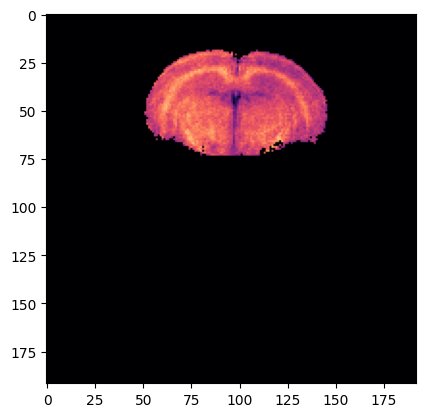

In [7]:
# --- Reconstruct Original Image ---
Healthy_Voxel_img_train = Rat_Z_Spectras_HEALTHY_TRAIN_sparse
inds = Rat_Healthy_Idx__HEALTHY_TRAIN_sparse
tempImg = np.zeros((4,192,192,8))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 8)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_HEALTHY_TRAIN_sparse     # Assign values at indexed positions
Healthy_Voxel_img_train = tempImg_flat.reshape((4,192,192,8))  # Reshape back
Healthy_Voxel_img_train.shape
Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 8)
print(Train_Image_Set.shape)
Train_Image_Set_indx = np.where(Train_Image_Set.sum(axis=1) >0)
train_extracted = Train_Image_Set[Train_Image_Set_indx]
train_extracted.shape

plt.imshow(Healthy_Voxel_img_train[3,:,:,0], vmin = 0, vmax=0.5, cmap='magma')



In [8]:
train_extracted.shape

(16548, 8)

In [9]:
print(Train_Image_Set.shape)

(147456, 8)


In [10]:
# --- Reconstruct Original Image ---
Tumor_Voxel_img =1- Rat_Z_Spectras_sparse
inds = Rat_Tumor_Idx
tempImg = np.zeros((4, 192, 192,8)) # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 8)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_tumor_all_sparse # Assign values at indexed positions
Tumor_Voxel_img = tempImg_flat.reshape((4, 192, 192,8))  # Reshape back
Tumor_Voxel_img.shape

(4, 192, 192, 8)

(4, 192, 192, 8)


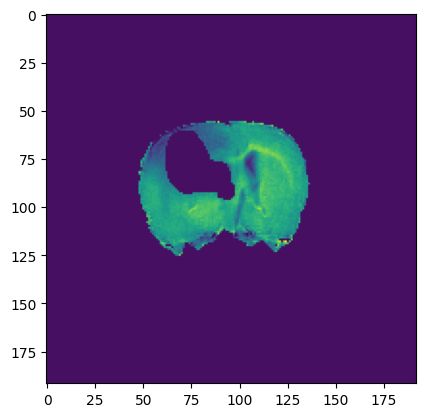

In [11]:
# --- Reconstruct Original Image ---
rat_image_shape = (4,192,192,8)
Healthy_Voxel_img_postGAD = Rat_Z_Spectras_sparse
inds = Rat_Healthy_Idx_sparse
tempImg = np.zeros(rat_image_shape)  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 8)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_sparse   # Assign values at indexed positions
Healthy_Voxel_img_postGAD = tempImg_flat.reshape(rat_image_shape)  # Reshape back
print(Healthy_Voxel_img_postGAD.shape)
plt.imshow(Healthy_Voxel_img_postGAD[2,:,:,0])


In [12]:


Test_Image_Set = Tumor_Voxel_img.reshape(-1, 8)
print(Test_Image_Set.shape)
Test_Image_Set_indx = np.where(Test_Image_Set.sum(axis=1) > 0)[0]
Healthy_test = Healthy_Voxel_img_postGAD.reshape(-1, 8)
Healthy_test_idx = np.where(Healthy_test.sum(axis=1) > 0)[0]
test_idx =np.concatenate([Test_Image_Set_indx,Healthy_test_idx])
print(Test_Image_Set_indx.shape)




(147456, 8)
(1495,)


In [13]:


test_extracted= np.concatenate([Rat_Z_Spectras_sparse[Test_Image_Set_indx],Rat_Z_Spectras_sparse[Healthy_test_idx]], axis=0)
test_extracted.shape
Test_img =Rat_Z_Spectras_sparse
inds = test_idx
tempImg = np.zeros((4,192,192,8))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 8)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  test_extracted      # Assign values at indexed positions
Test_img = tempImg_flat.reshape((4,192,192,8))  # Reshape back
print(Test_img.shape)


(4, 192, 192, 8)


In [14]:

Healthy_Voxel_img_all   = Healthy_Voxel_img_train
Healthy_Voxel_img_train = Healthy_Voxel_img_all[:3]        
Healthy_Voxel_img_val   = Healthy_Voxel_img_all[-1]       

Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 8)
Val_Image_Set   = Healthy_Voxel_img_val.reshape(-1, 8)

train_extracted = Train_Image_Set
val_extracted   = Val_Image_Set
print("train_extracted:", train_extracted.shape)
print("val_extracted:  ", val_extracted.shape)


train_extracted: (110592, 8)
val_extracted:   (36864, 8)


In [15]:

rat_train_data   = train_extracted
rat_val_data     = val_extracted
rat_test_data    = test_extracted

rat_train_labels = np.ones(len(rat_train_data), dtype=int)   # all healthy
rat_val_labels   = np.ones(len(rat_val_data),   dtype=int)   # all healthy
rat_test_labels  = np.concatenate(
    [np.ones(len(Test_Image_Set_indx)), np.zeros(len(Healthy_test_idx))],
    axis=0
).astype(int)

print("Train data shape:", rat_train_data.shape)
print("Val   data shape:", rat_val_data.shape)
print("Test  data shape:", rat_test_data.shape)
print("Train label counts:", np.unique(rat_train_labels, return_counts=True))
print("Val   label counts:", np.unique(rat_val_labels,   return_counts=True))
print("Test  label counts:", np.unique(rat_test_labels,  return_counts=True))


Train data shape: (110592, 8)
Val   data shape: (36864, 8)
Test  data shape: (14238, 8)
Train label counts: (array([1]), array([110592]))
Val   label counts: (array([1]), array([36864]))
Test  label counts: (array([0, 1]), array([12743,  1495]))


In [16]:
X_train = torch.from_numpy(rat_train_data).float().unsqueeze(1)  # (N,1,52)
X_val   = torch.from_numpy(rat_val_data).float().unsqueeze(1)
X_test  = torch.from_numpy(rat_test_data).float().unsqueeze(1)


In [17]:

print("new shape: ", X_train.shape, X_val.shape, X_test.shape)


new shape:  torch.Size([110592, 1, 8]) torch.Size([36864, 1, 8]) torch.Size([14238, 1, 8])


In [18]:

train_ds = TensorDataset(X_train)
val_ds   = TensorDataset(X_val)
test_ds  = TensorDataset(X_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)
y_train, y_val, y_test = rat_train_labels, rat_val_labels, rat_test_labels


In [19]:

R, H, W, O = Tumor_Voxel_img.shape
print(f"Expected 8 offsets, got {O}")

VAL_RAT_ID = 2  
block = H * W
start = VAL_RAT_ID * block
end   = start + block


Expected 8 offsets, got 8


In [20]:

# Masks to select flat indices for the held-out rat
tumor_mask_val   = (Test_Image_Set_indx >= start) & (Test_Image_Set_indx < end)
healthy_mask_val = (Healthy_test_idx   >= start)  & (Healthy_test_idx   < end)


In [21]:

#HOLDOUT VS TEST SET 
tumor_idx_val    = Test_Image_Set_indx[tumor_mask_val]
healthy_idx_val  = Healthy_test_idx[healthy_mask_val]
tumor_idx_test   = Test_Image_Set_indx[~tumor_mask_val]
healthy_idx_test = Healthy_test_idx[~healthy_mask_val]


In [22]:

val_unhealthy_extracted = np.vstack([
    Rat_Z_Spectras_sparse[tumor_idx_val],
    Rat_Z_Spectras_sparse[healthy_idx_val]
]).astype(np.float32)  # (N_val_unhealthy, 26)

rat_test_extracted = np.vstack([
    Rat_Z_Spectras_sparse[tumor_idx_test],
    Rat_Z_Spectras_sparse[healthy_idx_test]
]).astype(np.float32)  # (N_test, 26)

# Labels: tumor=1, healthy=0
y_val_unhealthy = np.concatenate([
    np.ones(len(tumor_idx_val),    dtype=int),
    np.zeros(len(healthy_idx_val), dtype=int)
])
y_test = np.concatenate([
    np.ones(len(tumor_idx_test),    dtype=int),
    np.zeros(len(healthy_idx_test), dtype=int)
])


In [23]:


rat_test_data   = rat_test_extracted
rat_test_labels = y_test
X_test          = torch.from_numpy(rat_test_data).float().unsqueeze(1)           # (N,1,26)
test_loader     = DataLoader(TensorDataset(X_test), batch_size=128, shuffle=False)

X_val_unhealthy     = torch.from_numpy(val_unhealthy_extracted).float().unsqueeze(1)  # (M,1,26)
val_unhealthy_loader= DataLoader(TensorDataset(X_val_unhealthy), batch_size=128, shuffle=False)


In [24]:

print("Held-out Unhealthy VAL (8):", val_unhealthy_extracted.shape, y_val_unhealthy.shape)
print("Two-rat TEST (8):          ", rat_test_extracted.shape,      y_test.shape)


Held-out Unhealthy VAL (8): (4927, 8) (4927,)
Two-rat TEST (8):           (9311, 8) (9311,)


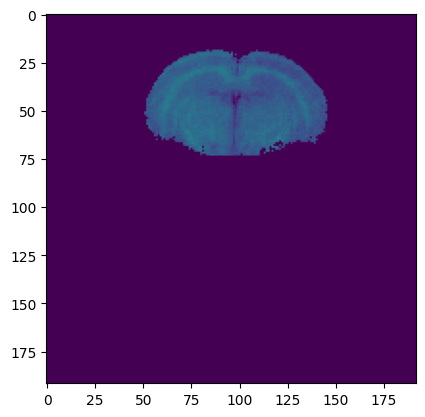

In [25]:
plt.imshow(Healthy_Voxel_img_val[:,:,0], vmin = 0, vmax =1, )

## Load Model

In [26]:
cae_model = ConvolutionalAE_upd(seq_len=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_cae = "Checkpoints/UPDATED OFFSETS_NEW OPTIMAL/sancheck_8_Off_B0Corrected_AMAS_best_model_usethis.pth"

state_dict = torch.load(checkpoint_cae, map_location=torch.device('cpu'))
cae_model.load_state_dict(state_dict)
cae_model.to(device)


ConvolutionalAE_upd(
  (conv_down1): Sequential(
    (0): Conv1d(1, 8, kernel_size=(3,), stride=(1,), padding=same)
    (1): GELU(approximate='none')
    (2): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=same)
    (3): GELU(approximate='none')
  )
  (max_pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_down2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (1): GELU(approximate='none')
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=same)
    (3): GELU(approximate='none')
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fnn_down): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16, bias=True)
    (3): ReLU()
  )
  (fnn_up): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Un

In [27]:
cae_test_results = test(cae_model,test_loader)
cae_val_unhealthy_rec = test(cae_model, val_unhealthy_loader)

# ###################################################################################################################################################

### Generate ROC

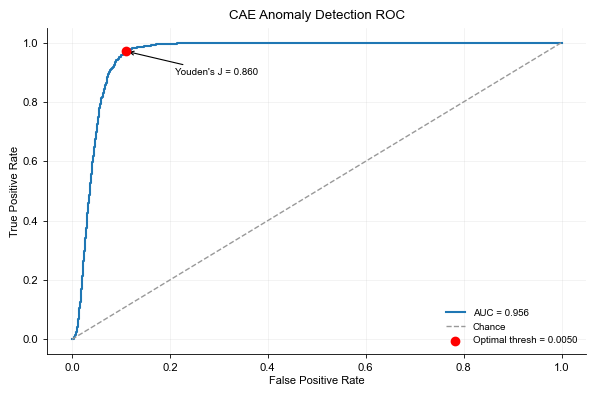

In [28]:
recon = X_test.squeeze(1)  # torch tensor, shape (N, features)
recon_errors = reconstruction_error(recon.cpu().numpy(), cae_test_results)  # (N,)
y_true = rat_test_labels  # binary array
metrics = roc_analysis(y_true, recon_errors, pos_label=1)
fig, ax = plot_roc_clean(metrics)

In [29]:
print("=== ROC Summary ===")
print(summary_text(metrics))

=== ROC Summary ===
AUC: 0.956
Optimal threshold (Youden's J): 0.0050
Sensitivity: 0.971
Specificity: 0.889
Fraction flagged as anomaly: 17.1%
Threshold percentile: 83.0th



In [30]:
## VALIDATION ROC
recon = X_val_unhealthy.squeeze(1)
recon_errors_val =reconstruction_error(recon.cpu().numpy(), cae_val_unhealthy_rec)  # (N,)
y_true_val = y_val_unhealthy  # binary array
metrics = roc_analysis(y_true_val, recon_errors_val, pos_label=1)
# fig, ax = plot_roc_clean(metrics, save_path="figure_roc_cae.pdf")

In [31]:
print("=== ROC Summary ===")
print(summary_text(metrics))

=== ROC Summary ===
AUC: 0.874
Optimal threshold (Youden's J): 0.0026
Sensitivity: 0.908
Specificity: 0.775
Fraction flagged as anomaly: 34.3%
Threshold percentile: 65.7th



In [32]:

healthy_inds = np.where(y_true_val == 0)[0]
# thrshold_percentage =0.90
thrshold_percentage =0.90
threshold_unsupervised = np.quantile(recon_errors_val[healthy_inds], thrshold_percentage)  # 99th percentile
print(f"Unsupervised  = {threshold_unsupervised:.5f}")


Unsupervised  = 0.00922


In [33]:
threshold_unsupervised

np.float32(0.00921776)

In [34]:

anomaly_score_val = recon_errors_val
norm_anom_score_cae = (anomaly_score_val - np.min(anomaly_score_val)) / (np.max(anomaly_score_val) - np.min(anomaly_score_val))
binary_score_val = (anomaly_score_val >=  threshold_unsupervised).astype(int)


In [35]:

anomaly_score_val = recon_errors_val.astype(float)
rng = anomaly_score_val.max() - anomaly_score_val.min()
norm_anom_score_val = (anomaly_score_val - anomaly_score_val.min()) / (rng if rng > 0 else 1.0)
binary_score_val = (anomaly_score_val >= float(threshold_unsupervised)).astype(np.uint8)

# 2) Flat index order must match how X_val_unhealthy was stacked: [tumor; healthy]
idx_order_val = np.concatenate([tumor_idx_val, healthy_idx_val])
assert idx_order_val.size == anomaly_score_val.shape[0], \
    f"VAL scores len {anomaly_score_val.shape[0]} != idx count {idx_order_val.size}"

# 3) Choose offsets dimension (26 if you built a sparse set, else 52)
if 'Rat_Z_Spectras_sparse' in globals():
    Rv, Hv, Wv, Ov = map(int, (3,192,192,26))   # e.g., (3,192,192,26)
else:
    Rv, Hv, Wv, Ov = map(int, rat_data_postGAD['imageShape']) # e.g., (3,192,192,52)

# 4) Scatter scores to flat canvas then reshape
Nvox_val = Rv * Hv * Wv
flat_norm_val = np.zeros((Nvox_val, Ov), dtype=np.float32)
flat_bin_val  = np.zeros((Nvox_val, Ov), dtype=np.uint8)

flat_norm_val[idx_order_val] = np.repeat(norm_anom_score_val[:, None], Ov, axis=1)
flat_bin_val[idx_order_val]  = np.repeat(binary_score_val[:,    None], Ov, axis=1)

anom_norm_img_val = flat_norm_val.reshape(Rv, Hv, Wv, Ov)
bin_img_val       = flat_bin_val.reshape(Rv, Hv, Wv, Ov)

# 5) Zero out non-validation rats (keep ONLY VAL_RAT_ID populated)
for ri in range(Rv):
    if ri != VAL_RAT_ID:
        anom_norm_img_val[ri] = 0.0
        bin_img_val[ri]       = 0

print("anom_norm_img_val:", anom_norm_img_val.shape,
      "| nonzero@offset0:", int((anom_norm_img_val[...,0] > 0).sum()))
print("bin_img_val:", bin_img_val.shape,
      "| positives@offset0:", int(bin_img_val[...,0].sum()))


anom_norm_img_val: (3, 192, 192, 26) | nonzero@offset0: 4926
bin_img_val: (3, 192, 192, 26) | positives@offset0: 875


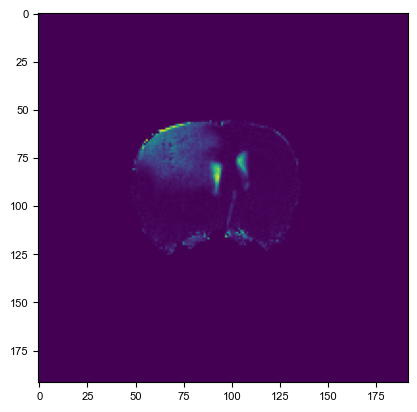

In [36]:
plt.imshow(anom_norm_img_val[2,:,:,0],vmin=0, vmax=1)


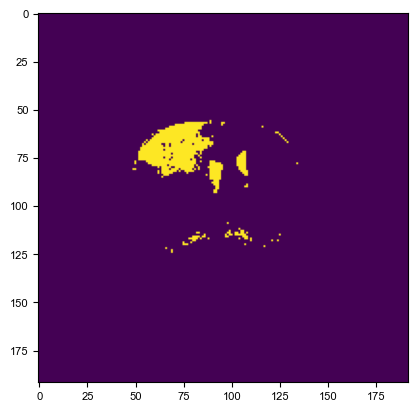

In [37]:
plt.imshow(bin_img_val[2,:,:,0])


In [38]:

anomaly_score_cae = recon_errors
norm_anom_score_cae = (anomaly_score_cae - np.min(anomaly_score_cae)) / (np.max(anomaly_score_cae) - np.min(anomaly_score_cae))
binary_score_cae = (anomaly_score_cae >=  threshold_unsupervised).astype(int)


In [39]:

recon_errors_test = recon_errors
Nvox = R * H * W
anom_flat = np.zeros(Nvox, dtype=float)

split_t = len(tumor_idx_test)
anom_flat[tumor_idx_test]   = recon_errors_test[:split_t]
anom_flat[healthy_idx_test] = recon_errors_test[split_t:]
anom_img_3d  = anom_flat.reshape(R, H, W)
anom_img_cae = np.repeat(anom_img_3d[..., None], O, axis=-1)

print("anom_img_cae:", anom_img_cae.shape, " | nonzero voxels:", np.count_nonzero(anom_img_3d))


anom_img_cae: (4, 192, 192, 8)  | nonzero voxels: 9311


(np.float64(-0.5), np.float64(191.5), np.float64(191.5), np.float64(-0.5))

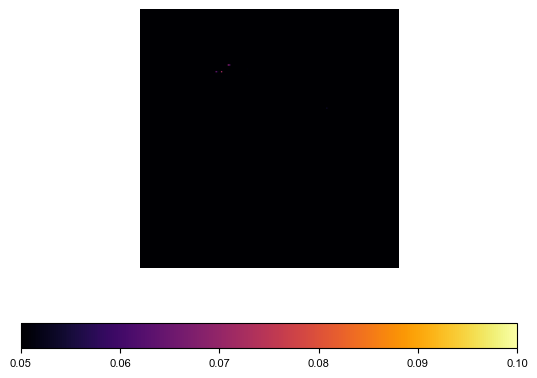

In [40]:
plt.imshow(anom_img_cae[1,:,:,0], cmap = "inferno",vmin= 0.05, vmax = 0.1)
plt.colorbar(orientation= "horizontal")
plt.axis("off")

In [41]:
idx_order = np.concatenate([tumor_idx_test, healthy_idx_test])


In [42]:

assert anomaly_score_cae.shape[0] == idx_order.shape[0], \
    f"Scores length {anomaly_score_cae.shape[0]} != num test voxels {idx_order.shape[0]}"


In [43]:

# Total voxels across all rats
Nvox = R * H * W

# Initialize flat arrays: (total_voxels, num_offsets)
flat_norm = np.zeros((Nvox, O), dtype=np.float32)  # normalized anomaly scores
flat_bin  = np.zeros((Nvox, O), dtype=np.uint8)    # binary anomaly mask

norm_2d = np.repeat(norm_anom_score_cae[:, None], O, axis=1).astype(np.float32)
bin_2d  = np.repeat(binary_score_cae[:, None], O, axis=1).astype(np.uint8)



# Place test voxel predictions into the full volume grid
flat_norm[idx_order] = norm_2d
flat_bin[idx_order]  = bin_2d

# Reshape from flat arrays into 4D brain volumes
anom_norm_img_cae = flat_norm.reshape(R, H, W, O)  # continuous anomaly scores [0, 1]
bin_img_cae       = flat_bin.reshape(R, H, W, O)   # binary anomaly predictions {0, 1}

# ============================================================================
# Zero out the validation rat (exclude from test set visualization)
# ============================================================================

anom_norm_img_cae[VAL_RAT_ID] = 0.0
bin_img_cae[VAL_RAT_ID]       = 0

# ============================================================================
# Summary statistics
# ============================================================================

print("anom_norm_img_cae:", anom_norm_img_cae.shape,
      "| nonzero @ offset0:", int((anom_norm_img_cae[..., 0] > 0).sum()))
print("bin_img_cae:", bin_img_cae.shape,
      "| positives @ offset0:", int(bin_img_cae[..., 0].sum()))

anom_norm_img_cae: (4, 192, 192, 8) | nonzero @ offset0: 9310
bin_img_cae: (4, 192, 192, 8) | positives @ offset0: 1190


In [44]:
# fig, axes = plot_tumor_detection(bin_img_cae, Tumor_Voxel_img, save_path="tumor_detection.png")

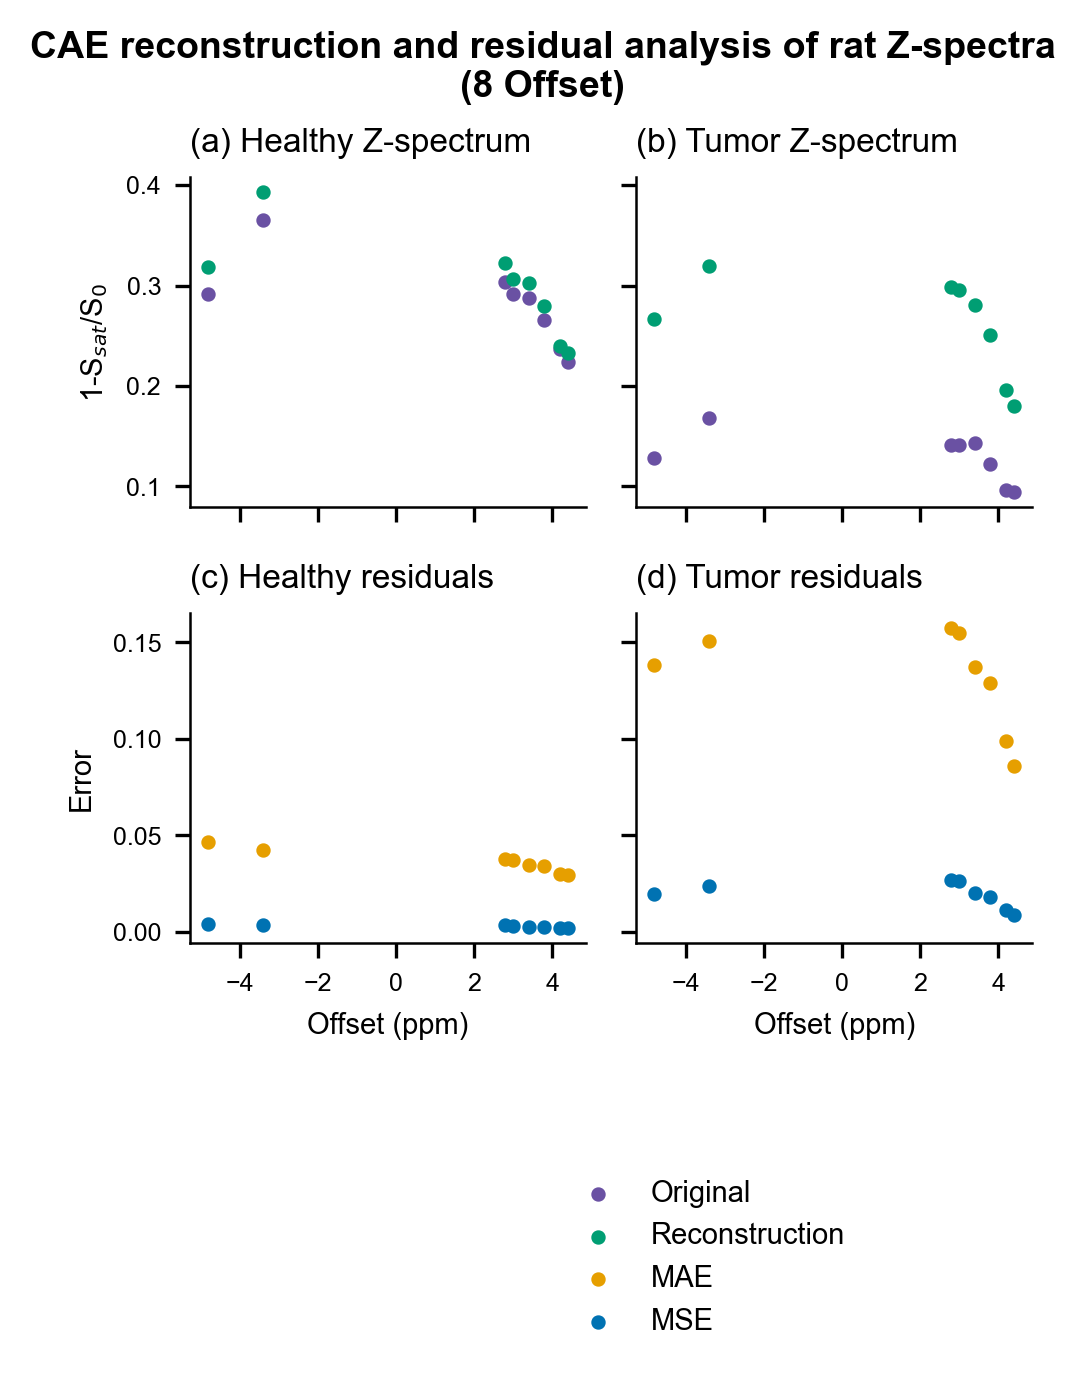

In [45]:
offset_axis = top8.item()['offsets']
fig, axes = plot_zspec_recon_and_residuals_scatter(
    orig=X_test,                # (N,1,52) or (N,52) or torch.Tensor
    rec=cae_test_results,       # (N,52)
    y_true=rat_test_labels,     # (N,)
    offset_axis=offset_axis,
    save_path=None,             # e.g., "zspec_summary.pdf"
    show=True
)



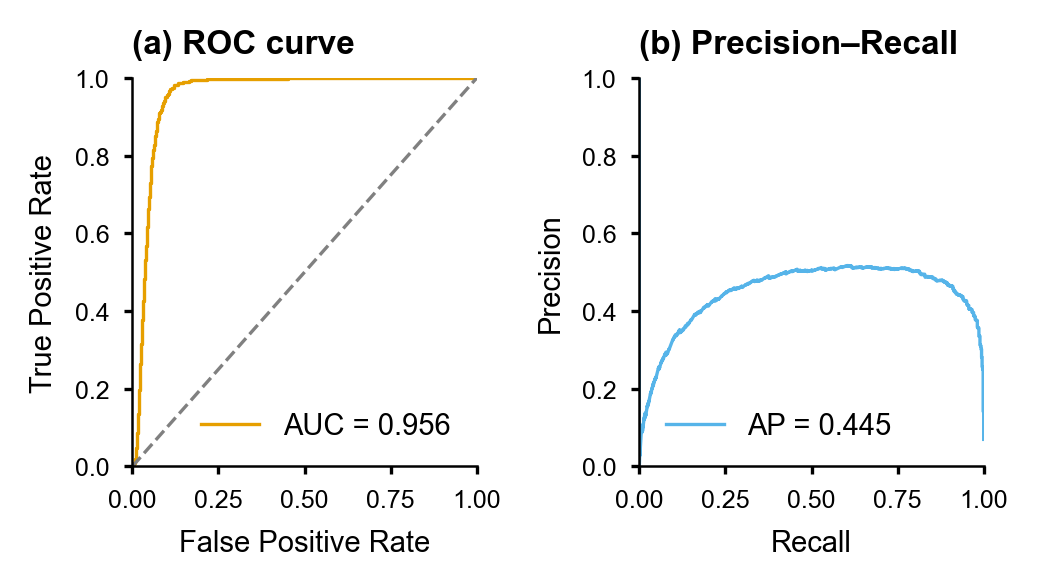

In [46]:
fig, axes = plot_roc_pr(y_true=rat_test_labels, scores=recon_errors,
                        pos_label=1, save_path=None, show=True)


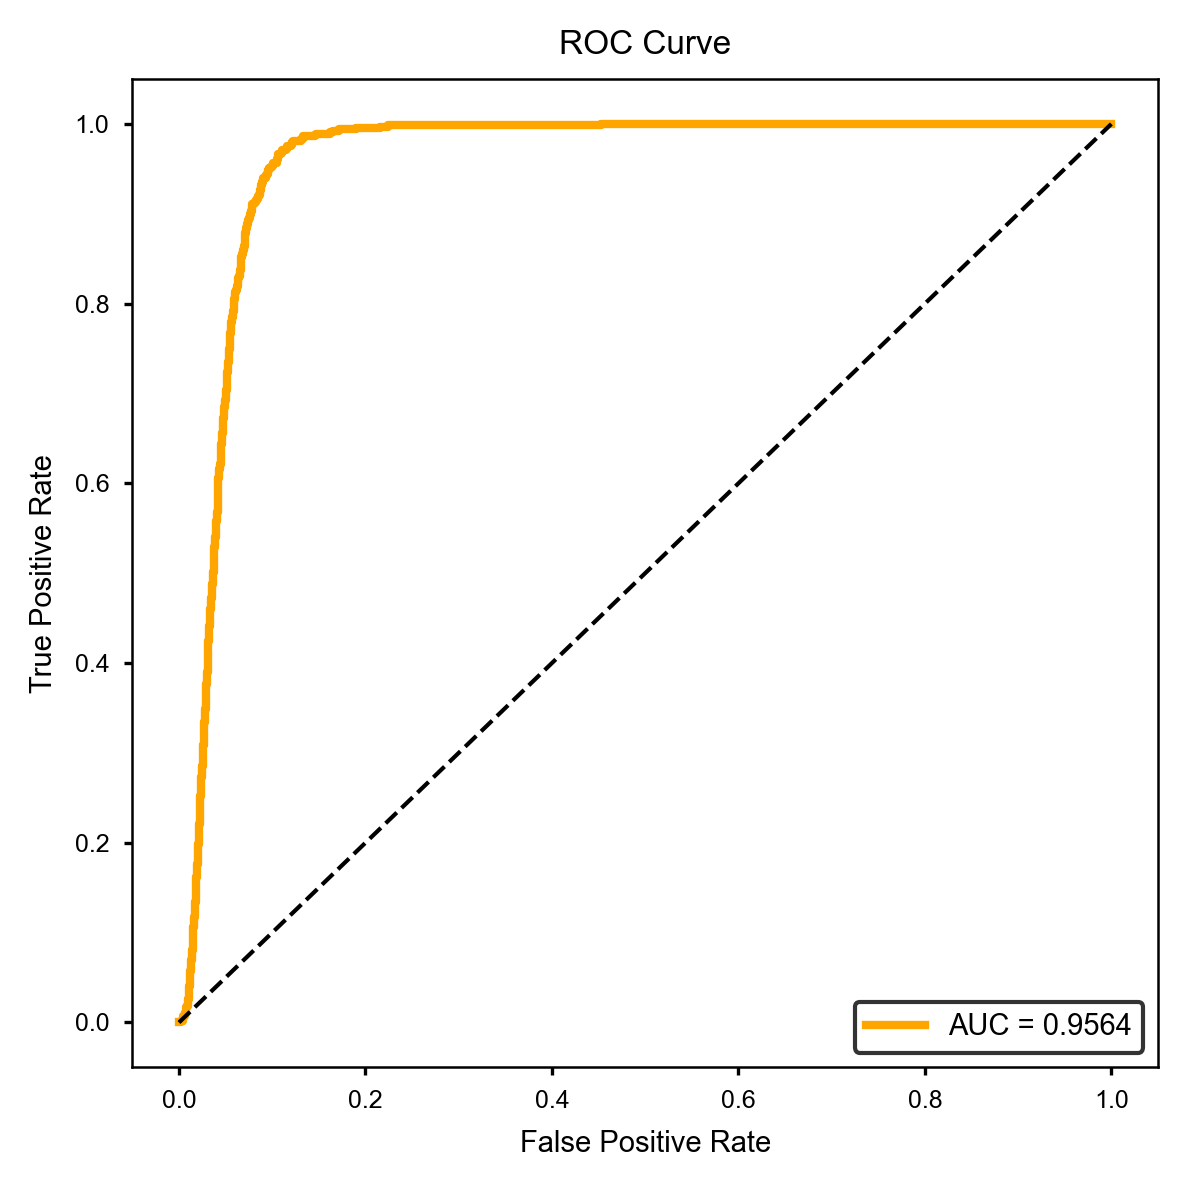

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC
fpr, tpr, _ = roc_curve(rat_test_labels, recon_errors)
auc_val = roc_auc_score(rat_test_labels, recon_errors)

# Plot
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, color="orange", label=f"AUC = {auc_val:.4f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# Legend with box
plt.legend(loc="lower right", frameon=True, edgecolor="black")

plt.tight_layout()
plt.show()


In [48]:
fpr1, tpr1, _ = roc_curve(rat_test_labels, recon_errors)
auc1 = roc_auc_score(rat_test_labels, recon_errors)

# Save ROC data
np.savez("./metrics/roc8Offset_Optimal.npz", fpr=fpr1, tpr=tpr1, auc=auc1)

print("Saved ROC data to roc8Offset_Optimal.npz")


Saved ROC data to roc8Offset_Optimal.npz


In [49]:
nifti_image = nib.load('./data/CDF1T1.nii')
cdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('./data/SDF1T1.nii')
sdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('./data/SDF4T1.nii')
sdf4_T1 = nifti_image.get_fdata()
#
cdf1_T1 = np.rot90(cdf1_T1[:, :, 5],k = 3)

sdf4_T1 = np.rot90(sdf4_T1[:, :, 4],k = 3)

sdf1_T1 = np.rot90(sdf1_T1[:, :, 6],k = 3)

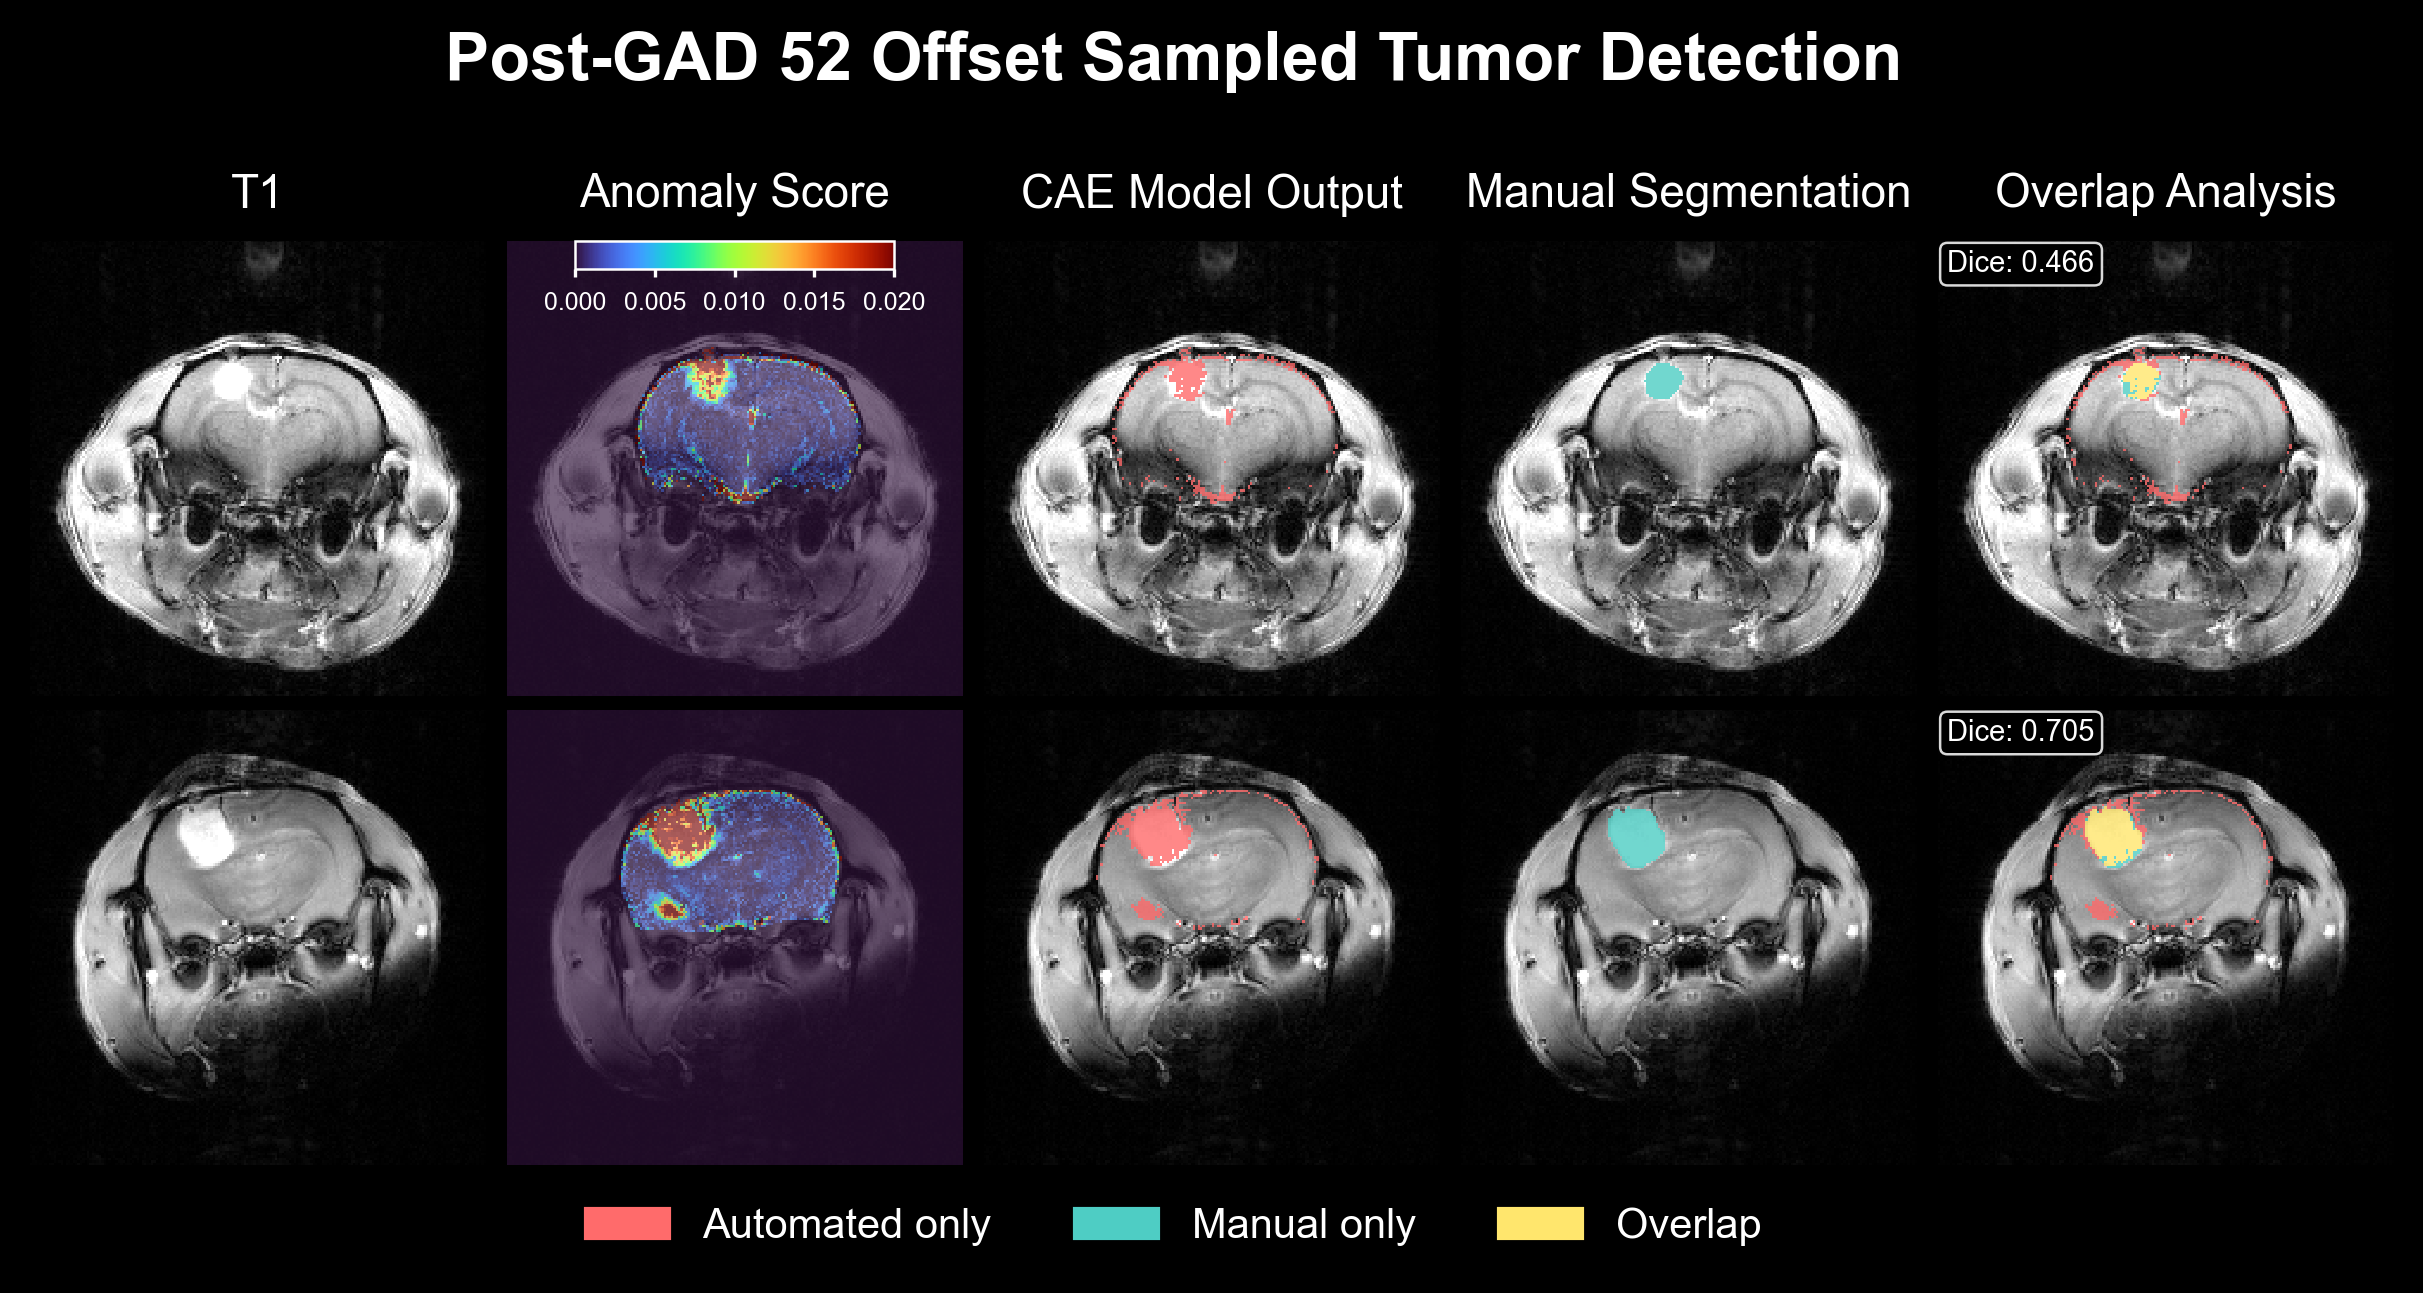

(<Figure size 3060x1320 with 11 Axes>,
 array([[<Axes: title={'center': 'T1'}>,
         <Axes: title={'center': 'Anomaly Score'}>,
         <Axes: title={'center': 'CAE Model Output'}>,
         <Axes: title={'center': 'Manual Segmentation'}>,
         <Axes: title={'center': 'Overlap Analysis'}>],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [50]:
plt.style.use('dark_background')  
t1_slices = (sdf4_T1, cdf1_T1, sdf1_T1)
auto2d  = bin_img_cae[..., 0].astype(bool)      # (3,H,W)
truth2d = Tumor_Voxel_img[..., 0].astype(bool)  # (3,H,W)

anom_3xHW = np.stack([
    anom_img_cae[0, ..., 0],
    anom_img_cae[1, ..., 0],
    anom_img_cae[2, ..., 0],
], axis=0)

plot_masks_over_t1_slices(
    t1_slices,
    auto2d,
    truth2d,
    anom_maps=anom_3xHW,
    anom_vmin = 0,
    anom_vmax = 0.02,
    anom_cmap='turbo',
    anom_alpha=0.65,
    save_path="tumor_detection_with_blankT1.png"
)


In [51]:

def load_rotate_transpose(path):
    vols     = np.load(path)["data"]          # (5, 192, 192)
    vols_rot = np.rot90(vols, k=-1, axes=(1,2))
    arr      = np.transpose(vols_rot, (1,2,0))  # (192, 192, 5)
    return arr
SDF1 = load_rotate_transpose('data/sdf1.npz')
print("SDF1 shape:", SDF1.shape)
SDF4 = load_rotate_transpose('data/sdf4.npz')
print("SDF4 shape:", SDF4.shape)
CDF1 = load_rotate_transpose('data/cdf1.npz')
print("CDF1 shape:", CDF1.shape)
CDF3 = load_rotate_transpose('data/cdf3.npz')
CDF3 = CDF3.transpose(1,2,0)
print("CDF3 shape:", CDF3.shape)

SDF1 shape: (192, 192, 5)
SDF4 shape: (192, 192, 5)
CDF1 shape: (192, 192, 5)
CDF3 shape: (192, 192, 5)


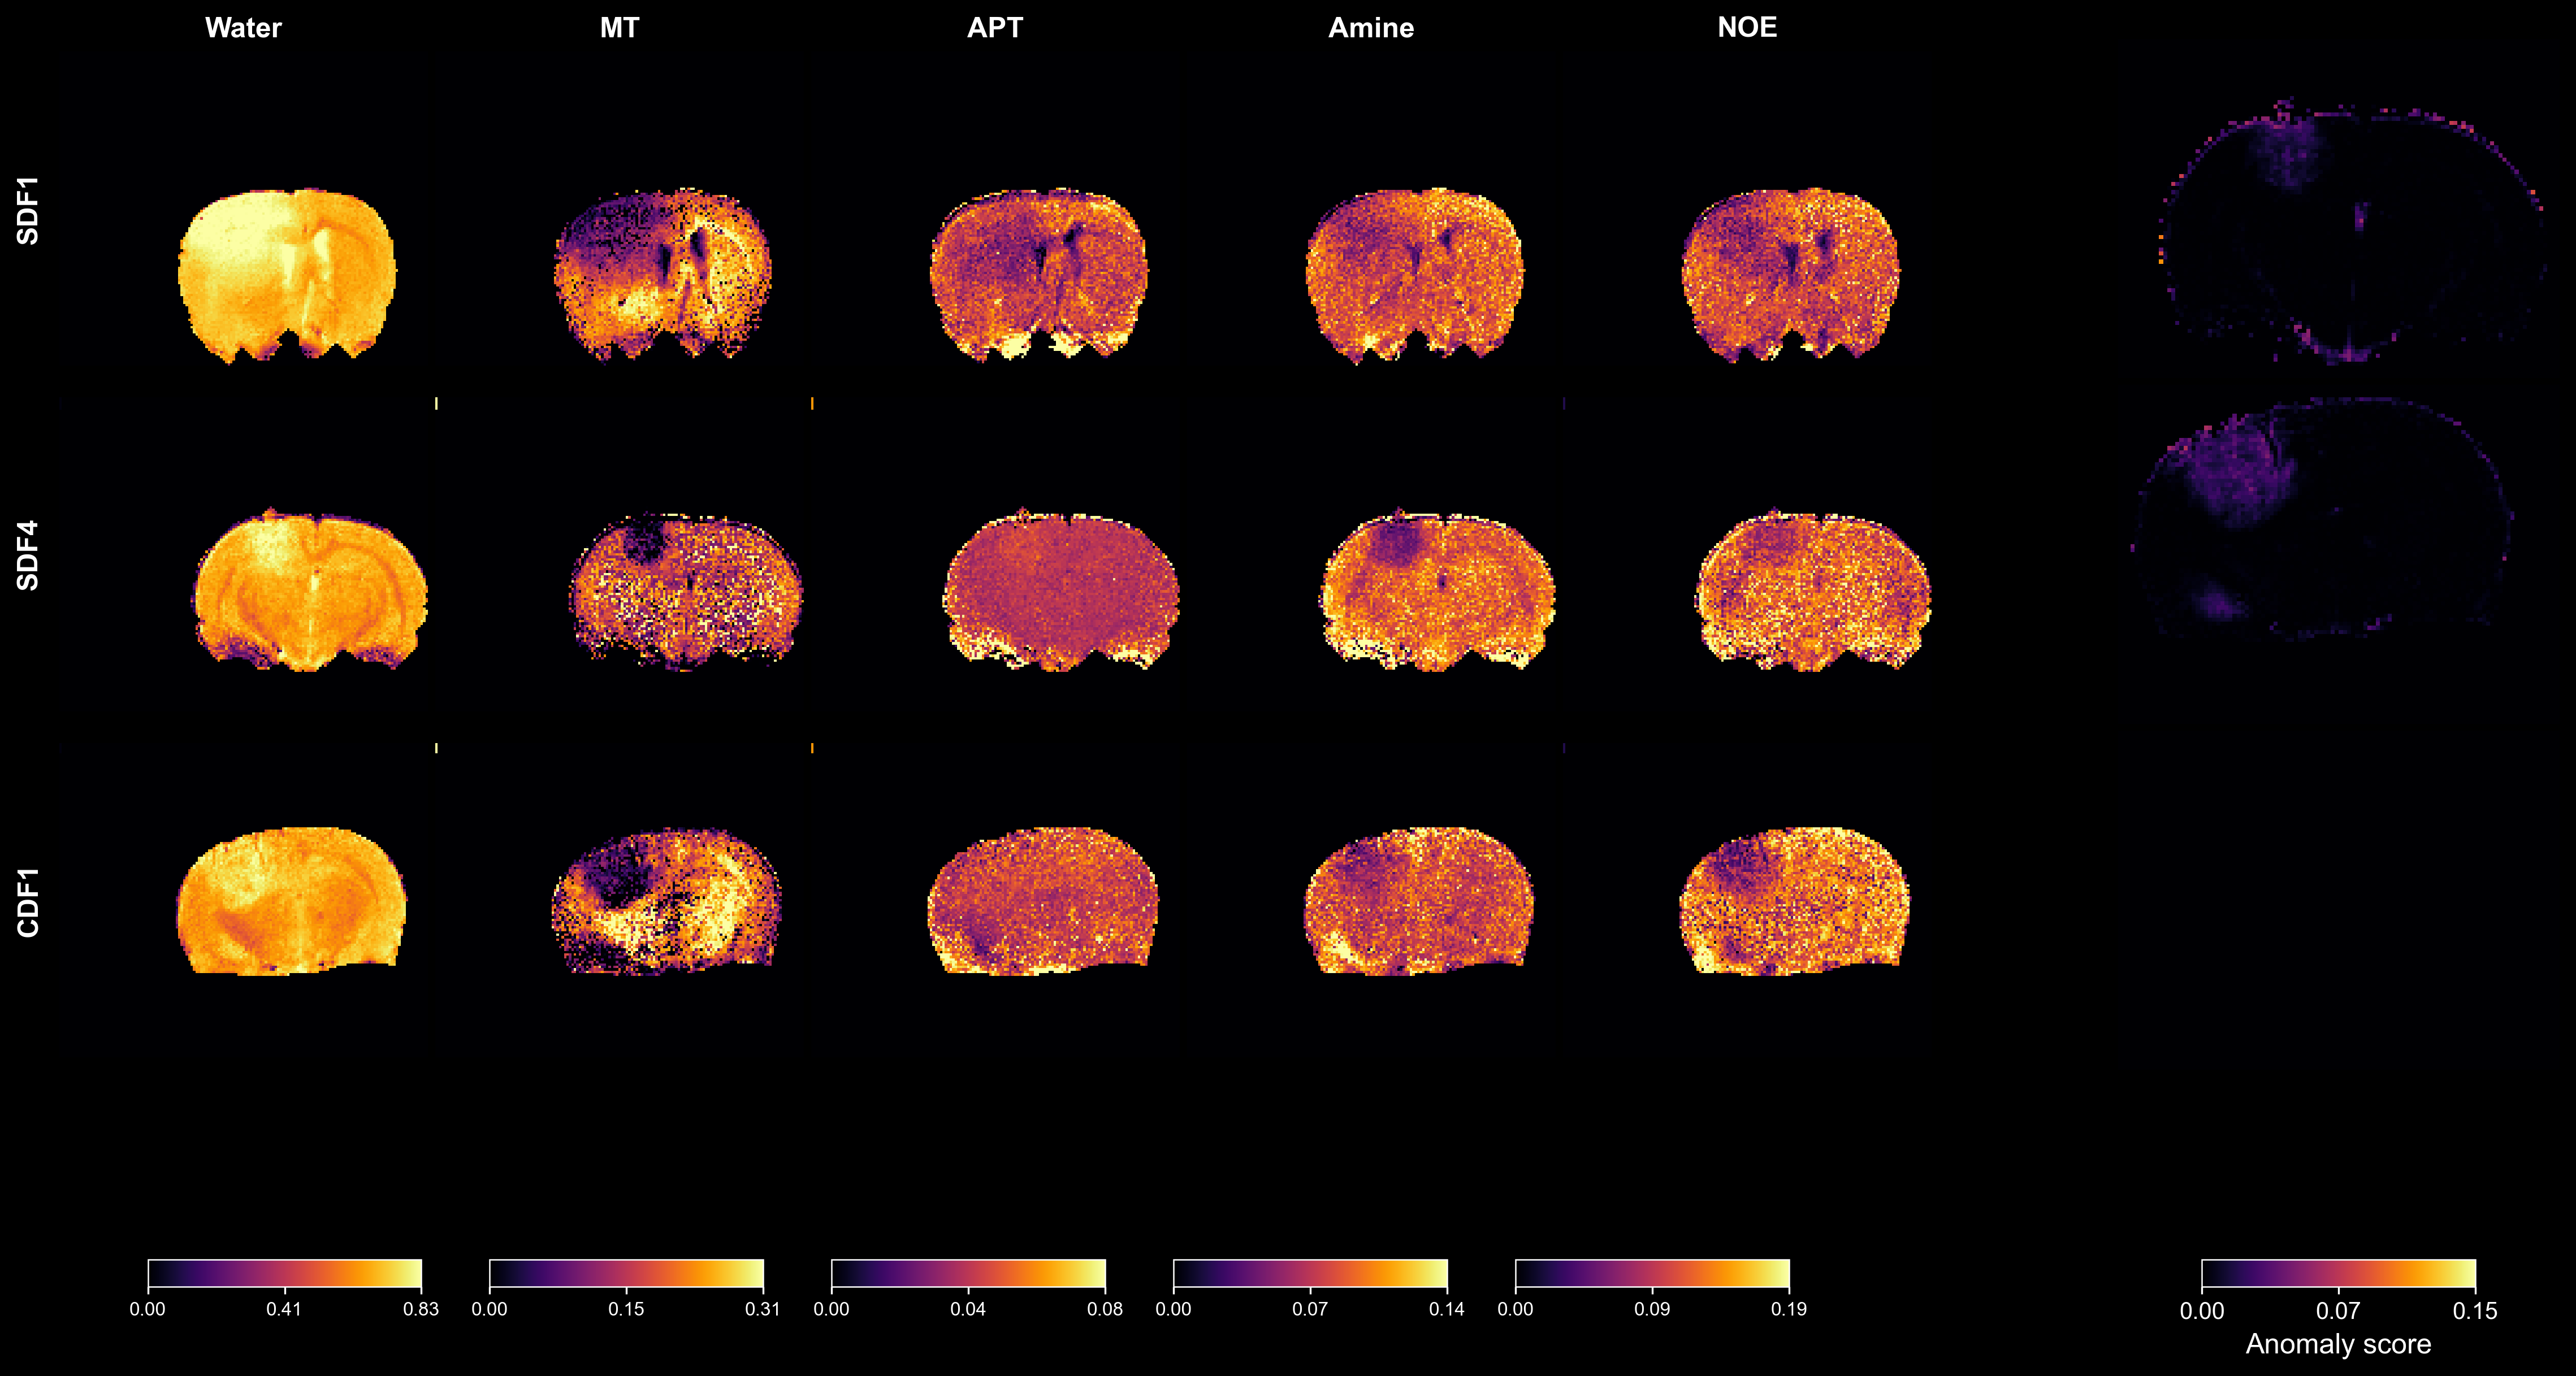

In [52]:
fig = plot_combined_grid_and_anomaly(SDF1, SDF4, CDF1, anom_img_cae)
plt.show()


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# Compute ROC
fpr1, tpr1, _ = roc_curve(rat_test_labels, recon_errors)
auc1 = roc_auc_score(rat_test_labels, recon_errors)

# Save ROC data
np.savez("roc8Offset_Optimal.npz", fpr=fpr1, tpr=tpr1, auc=auc1)

print("Saved ROC data to roc8Offset_Optimal.npz")


Saved ROC data to roc8Offset_Optimal.npz


In [54]:
# --- 1) Prep data ---
orig = np.asarray(X_test).squeeze()        # (N, 52) from torch.Tensor or np
rec  = np.asarray(cae_test_results)       # (N, 52)
y    = np.asarray(rat_test_labels)        # (N,)

# CAE anomaly score = MAE per voxel
scores = np.mean((orig - rec)**2, axis=1)

# --- 2) Metrics ---
# ROC / AUC
fpr, tpr, thr = roc_curve(y, scores)
roc_auc = roc_auc_score(y, scores)

# PR / AUC
prec_arr, rec_arr, _ = precision_recall_curve(y, scores)
pr_auc = average_precision_score(y, scores)

# best threshold via Youden's J
j = tpr - fpr
best_thr = threshold_unsupervised

y_pred = (scores >= best_thr).astype(int)

acc  = accuracy_score(y, y_pred)
f1   = f1_score(y, y_pred)
prec = precision_score(y, y_pred)
rec_ = recall_score(y, y_pred)

# --- 3) One-row DataFrame for CAE ---
df_cae = pd.DataFrame([{
    "Model": "CAE",
    "Accuracy": acc,
    "F1": f1,
    "ROC AUC": roc_auc,
    "PR AUC": pr_auc,
    "Precision": prec,
    "Recall": rec_,
    "Dice 1": None,   # fill in if you have it
    "Dice 2": None,   # fill in if you have it
}]).round(3)

df_cae



,Model,Accuracy,F1,ROC AUC,PR AUC,Precision,Recall,Dice 1,Dice 2
0,CAE,0.925,0.62,0.956,0.445,0.479,0.88,None,None


In [55]:


# Ensure folder exists
os.makedirs("./metrics", exist_ok=True)

y_true = np.asarray(rat_test_labels)
scores = np.asarray(recon_errors)
fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = roc_auc_score(y_true, scores)
prec_curve, rec_curve, _ = precision_recall_curve(y_true, scores)
pr_auc = average_precision_score(y_true, scores)
threshold = threshold_unsupervised
y_pred = (scores >= threshold).astype(int)

# ------------------
# Classification metrics
# ------------------
acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)

os.makedirs("./metrics", exist_ok=True)
np.savez(
    "./metrics/metrics_8Offset_Optimal.npz",
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc,
    pr_auc=pr_auc,
    accuracy=acc,
    f1=f1,
    precision=prec,
    recall=rec,
    threshold=threshold
)

print("Saved to ./metrics/metrics_8Offset_Optimal.npz")
print("Threshold used:", threshold)


Saved to ./metrics/metrics_8Offset_Optimal.npz
Threshold used: 0.00921776
